# 02. Modern extraction: INE/PORDATA and CFP

Load the continuous modern B.9 bridge, independently parse the CFP ESA 2010 account and debt workbooks, and compare the two modern sources against each other before either is used downstream.

**Reads**

- `data/raw/pordata/pordata_2785_balance_by_level_1995_2025.csv`
- `data/raw/cfp/cfp_sec2010_annual_general_government_2026-04-15.xlsx`
- `data/raw/cfp/cfp_sec2010_annual_subsectors_2026-04-15.xlsx`
- `data/raw/cfp/cfp_rel_04_2026_social_security_underlying_data.xlsx`

**Writes**

- Nothing. The pipeline persists these extractions; here they are inspected.

**Method reference:** `METHODOLOGY.md` sections 3-4 and 10

In [1]:
"""Notebook environment: locate the repository and expose its data layers."""

import sys
import warnings
from pathlib import Path

import pandas as pd
from IPython.display import display

# Resolve the repository root from wherever the kernel was started, so the
# notebook works both from the repository root and from the notebooks directory.
ROOT = Path.cwd()
while not (ROOT / 'pyproject.toml').exists() and ROOT != ROOT.parent:
    ROOT = ROOT.parent
if str(ROOT / 'src') not in sys.path:
    sys.path.insert(0, str(ROOT / 'src'))

%matplotlib inline

from portugal_fiscal_balance.analysis import figures

RAW = ROOT / 'data' / 'raw'
INTERIM = ROOT / 'data' / 'interim'
PROCESSED = ROOT / 'data' / 'processed'
TABLES = ROOT / 'outputs' / 'tables'
METRICS = ROOT / 'outputs' / 'metrics'

warnings.filterwarnings('ignore', category=UserWarning, module='openpyxl')
pd.set_option('display.max_columns', 80)
pd.set_option('display.width', 200)

print('repository:', ROOT.name)
print('pipeline outputs present:', (PROCESSED / 'fiscal_balances_1977_2025.csv').exists())

repository: portugal-fiscal-balance
pipeline outputs present: True


## 1. Two independent modern sources

The modern segment uses one source as the continuous balance bridge and a second,
independently parsed source for detailed components:

- **INE via PORDATA** provides the four B.9 balances for 1995-2025 and is the
  canonical modern bridge;
- **CFP ESA 2010 workbooks** provide revenue, expenditure, interest, investment,
  Maastricht debt and stock-flow adjustments, and act as a cross-check on the
  bridge.

In [2]:
from portugal_fiscal_balance.sources.cfp import (
    extract_cfp_annual,
    extract_social_security_detail,
)
from portugal_fiscal_balance.sources.pordata import load_balance_snapshot

modern = load_balance_snapshot(RAW / 'pordata' / 'pordata_2785_balance_by_level_1995_2025.csv')
cfp = extract_cfp_annual(
    RAW / 'cfp' / 'cfp_sec2010_annual_general_government_2026-04-15.xlsx',
    RAW / 'cfp' / 'cfp_sec2010_annual_subsectors_2026-04-15.xlsx',
)
ss_systems, ss_detail = extract_social_security_detail(
    RAW / 'cfp' / 'cfp_rel_04_2026_social_security_underlying_data.xlsx'
)
print('pordata balance bridge:', modern.shape)
print('cfp accounts:', cfp.accounts.shape)
print('cfp debt and stock-flow:', cfp.debt.shape)

pordata balance bridge: (31, 6)
cfp accounts: (109, 45)
cfp debt and stock-flow: (109, 9)


In [3]:
display(modern.tail(8))

,year,general_government_balance_m_eur,central_government_balance_m_eur,regional_local_balance_m_eur,social_security_balance_m_eur,status
23,2018,-873,-3407,499,2035,final
24,2019,249,-3331,604,2975,final
25,2020,-11564,-13555,-207,2198,final
26,2021,-6117,-7985,-601,2468,final
27,2022,-757,-4966,-91,4299,final
28,2023,3030,-2447,-243,5720,final
29,2024,1863,-4424,256,6031,provisional
30,2025,2059,-5636,630,7065,provisional


## 2. Coverage of the CFP account panel

General Government components start in 1995; the three subsectors start in 2000.
That asymmetry is a property of the source and is preserved rather than filled.

In [4]:
coverage = cfp.accounts.groupby('sector')['year'].agg(['min', 'max', 'count'])
display(coverage)

,min,max,count
sector,,,
central_government,2000,2025,26
general_government,1995,2025,31
regional_local_government,2000,2025,26
social_security_funds,2000,2025,26


## 3. Do the two modern sources agree?

The PORDATA bridge is published rounded, and the CFP workbook is a separate
compilation, so exact equality is not expected. What matters is that the
differences stay at rounding scale instead of revealing a parsing error.

In [5]:
from portugal_fiscal_balance.processing.validation import compare_modern_balance_sources

comparison = compare_modern_balance_sources(modern, cfp.general_government, cfp.subsectors)
difference_columns = [column for column in comparison.columns if column.endswith('_source_difference_m_eur')]
summary = (
    comparison[difference_columns]
    .abs()
    .max()
    .rename('max_abs_difference_m_eur')
    .to_frame()
    .round(1)
)
display(summary)
display(comparison[['year', *difference_columns]].tail(8).round(1))

,max_abs_difference_m_eur
general_government_source_difference_m_eur,0.5
central_government_source_difference_m_eur,66.8
regional_local_source_difference_m_eur,0.5
social_security_source_difference_m_eur,0.5


,year,general_government_source_difference_m_eur,central_government_source_difference_m_eur,regional_local_source_difference_m_eur,social_security_source_difference_m_eur
23,2018,-0.2,-0.1,-0.2,0.2
24,2019,0.0,-0.1,-0.4,-0.5
25,2020,-0.1,-0.4,0.2,0.1
26,2021,0.0,-0.3,-0.4,-0.3
27,2022,0.3,0.1,-0.5,-0.4
28,2023,0.3,0.4,-0.0,-0.2
29,2024,0.5,-0.1,0.1,0.4
30,2025,0.4,-0.2,0.3,0.3


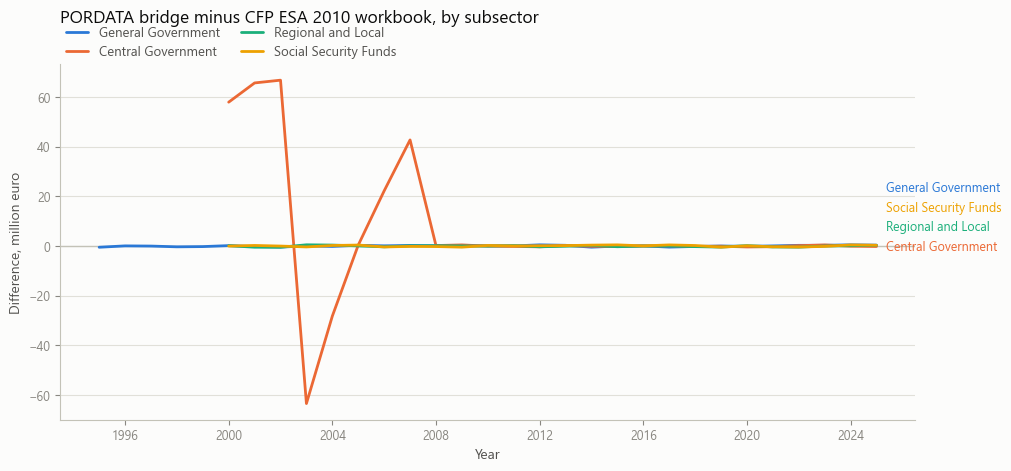

In [6]:
figure = figures.modern_source_differences(comparison)

## 4. Social Security budget tables

The CFP Social Security report is a **different accounting boundary** from the
ESA 2010 Social Security Funds sector. It is extracted here so that notebook 09
can analyse the internal Previdential / Citizenship / Special Regimes split
without merging it into the national-accounts balance.

In [7]:
display(ss_systems)
display(ss_detail.set_index('year').T)

,year,citizenship_system_balance_m_eur,previdential_system_balance_m_eur,special_regimes_balance_m_eur,source
0,2019,443.0,2333.0,0.0,CFP Social Security 2025 report underlying data
1,2020,423.0,1649.0,0.0,CFP Social Security 2025 report underlying data
2,2021,653.0,1695.0,0.0,CFP Social Security 2025 report underlying data
3,2022,-110.0,4172.0,0.0,CFP Social Security 2025 report underlying data
4,2023,1.0,5485.0,0.0,CFP Social Security 2025 report underlying data
5,2024,-245.0,5840.0,0.0,CFP Social Security 2025 report underlying data
6,2025,-55.0,6712.0,0.0,CFP Social Security 2025 report underlying data


year,2024,2025
social_contributions_m_eur,27688.0,30152.0
state_budget_transfers_m_eur,9199.0,9956.0
state_budget_lbss_transfers_m_eur,8620.0,9442.0
rsi_expenditure_m_eur,358.0,342.0
professional_training_subsidies_m_eur,41.0,96.0
social_security_budget_balance_m_eur,5591.0,6672.0
previdential_revenue_m_eur,30107.0,32679.0
previdential_contributions_m_eur,27688.0,30152.0
previdential_state_transfers_m_eur,322.0,317.0
previdential_training_employment_expenditure_m_eur,950.0,1031.0


## Interpretation limits

1. The PORDATA bridge is **rounded at source**. It is used for the balance panel,
   not for component-level arithmetic.
2. CFP figures for the most recent year are **provisional** in the same sense as
   the official statistics they compile.
3. Social Security budget-system tables and ESA 2010 Social Security Funds
   accounts are **never combined into one series**.

---

[Previous: 01. Historical extraction: Banco de Portugal / INE](01_extract_historical_data.ipynb) | [Next: 03. Harmonisation and validation](03_harmonize_and_validate.ipynb)

Every table shown above is also persisted as CSV, so results can be checked without reading notebook state. To rebuild everything from the bundled raw sources:

```bash
poetry install
make all
```